# Xử lý dữ liệu

In [9]:
from google.colab import drive
import pandas as pd

# 1. Kết nối và mount Google Drive của bạn
# Sau khi chạy dòng này, một cửa sổ sẽ hiện ra yêu cầu bạn xác thực và cấp quyền truy cập.
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
from google.colab import drive
import pandas as pd

# 1. Kết nối và mount Google Drive của bạn
try:
    drive.mount('/content/drive', force_remount=True)
    print("Google Drive đã được kết nối thành công!")
except Exception as e:
    print(f"Lỗi khi kết nối Google Drive: {e}")

# 2. Khai báo đường dẫn đến 2 file của bạn
file_excel_path = '/content/drive/MyDrive/SentimentAnalysis/Tiki_review_ABSA.xlsx'
file_csv_path = '/content/drive/MyDrive/SentimentAnalysis/tiki_products.csv'

try:
    # 3. Đọc dữ liệu từ 2 file vào DataFrame
    df_reviews = pd.read_excel(file_excel_path)
    df_products = pd.read_csv(file_csv_path)

    print("--- Thông tin 2 bảng ban đầu ---")
    print(f"Bảng review có {df_reviews.shape[0]} dòng và {df_reviews.shape[1]} cột.")
    print(f"Bảng product có {df_products.shape[0]} dòng và {df_products.shape[1]} cột.")

    # 4. Nối (merge) 2 DataFrame
    # left: Bảng bên trái (df_reviews)
    # right: Bảng bên phải (df_products)
    # left_on: Khóa nối của bảng bên trái ('product_id')
    # right_on: Khóa nối của bảng bên phải ('ID')
    # how: Kiểu nối. 'inner' sẽ chỉ giữ lại các dòng có ID tồn tại ở cả hai bảng.
    merged_df = pd.merge(df_reviews, df_products, left_on='product_id', right_on='ID', how='inner')

    # 5. In thông tin và xem kết quả của bảng đã nối
    print("\n--- Nối bảng thành công! ---")
    print(f"Bảng mới sau khi nối có {merged_df.shape[0]} dòng và {merged_df.shape[1]} cột.")

    print("\n--- 5 dòng đầu tiên của bảng đã nối ---")
    print(merged_df.head())

    print("\n--- Các cột của bảng đã nối ---")
    print(list(merged_df.columns))

except FileNotFoundError:
    print("\nLỖI: Không tìm thấy file. Vui lòng kiểm tra lại đường dẫn và tên file.")
    print(f"Đường dẫn đang kiểm tra: \n1. {file_excel_path}\n2. {file_csv_path}")
except Exception as e:
    print(f"Đã có lỗi xảy ra: {e}")

Mounted at /content/drive
Google Drive đã được kết nối thành công!
--- Thông tin 2 bảng ban đầu ---
Bảng review có 76978 dòng và 22 cột.
Bảng product có 1650 dòng và 10 cột.

--- Nối bảng thành công! ---
Bảng mới sau khi nối có 76978 dòng và 32 cột.

--- 5 dòng đầu tiên của bảng đã nối ---
   product_id  review_id  rating  \
0   270880693   19447515       5   
1   270880693   19586848       5   
2   270880693   19463849       5   
3   270880693   19458848       5   
4   270880693   19896681       5   

                                             content  likes    customer_name  \
0  mấy cái drama trong cuốn sách này ngày nào côn...      7        Hà Trương   
1  Cực kỳ hài lòng\nSản phẩm có chất lượng đúng n...      0   Japanit Matcha   
2  Tất cả mọi vấn đề mình đang gặp phải đều có tr...      3      Hầu Hải Yến   
3  Cái hay ho thú vị của quyển sách này không nằm...      3  Tăng Duy Phương   
4  Nội dung quá tuyệt vời cho tất cả intern nvien...      0        Huong Lan   

   created_

In [11]:
from google.colab import drive
import pandas as pd

# Thiết lập để pandas hiển thị nhiều cột hơn khi in ra
pd.set_option('display.max_columns', None)

# 1. Kết nối và mount Google Drive
try:
    drive.mount('/content/drive', force_remount=True)
except Exception as e:
    print(f"Lỗi khi kết nối Google Drive: {e}")

# 2. Đường dẫn đến file
file_excel_path = '/content/drive/MyDrive/SentimentAnalysis/Tiki_review_ABSA.xlsx'
file_csv_path = '/content/drive/MyDrive/SentimentAnalysis/tiki_products.csv'

try:
    # 3. Đọc và nối hai file
    df_reviews = pd.read_excel(file_excel_path)
    df_products = pd.read_csv(file_csv_path)
    merged_df = pd.merge(df_reviews, df_products, left_on='product_id', right_on='ID', how='inner')
    print("Nối file thành công. Bảng ban đầu có {} dòng.".format(merged_df.shape[0]))

    # 4. Xóa các cột không cần thiết
    columns_to_drop = [
        'created_at', 'customer_name', 'sentiment_score', 'content', 'segmented_content',
        'as_content_label_id', 'as_content_sentiment_score', 'as_physical_label_id',
        'as_physical_sentiment_score', 'as_price_label_id', 'as_price_sentiment_score',
        'as_packaging_label_id', 'as_packaging_sentiment_score', 'as_delivery_label_id',
        'as_delivery_sentiment_score', 'as_service_label_id', 'as_service_sentiment_score',
        'ID', 'Seller ID', 'Name', 'URL'
    ]
    # Dùng errors='ignore' để không báo lỗi nếu một cột nào đó không tồn tại
    df_cleaned = merged_df.drop(columns=columns_to_drop, errors='ignore')
    print("Xóa cột thành công.")

    # 5. Xử lý cột 'predicted_label_id' để tạo 3 cột label_count_0, 1, 2
    # Bước này cần thực hiện trước khi group by
    label_dummies = pd.get_dummies(df_cleaned['predicted_label_id'], prefix='label_count').astype(int)
    df_with_labels = pd.concat([df_cleaned, label_dummies], axis=1)

    # 6. Group by theo 'product_id' và tính toán các giá trị tổng hợp
    # Xác định các cột không thay đổi theo từng review để lấy giá trị đầu tiên
    static_cols = ['Price (After Discount)', 'Price (Before Discount)', 'Sales Count', 'Rating Average', 'Number Reviews', 'Discount Rate']

    # Tạo dictionary để định nghĩa các phép tính
    agg_functions = {
        'review_id': 'count', # Đếm số review
        'rating': 'mean',     # Trung bình rating
        'likes': 'sum',       # Tổng số likes
        'label_count_0': 'sum',
        'label_count_1': 'sum',
        'label_count_2': 'sum',
    }
    # Thêm các cột tĩnh vào dictionary
    for col in static_cols:
        agg_functions[col] = 'first' # Lấy giá trị đầu tiên vì nó giống nhau cho cả nhóm

    # Thực hiện group by và aggregation
    final_df = df_with_labels.groupby('product_id').agg(agg_functions)

    # Đổi tên cột 'review_id' thành 'review_count' cho rõ nghĩa
    final_df = final_df.rename(columns={'review_id': 'review_count'})

    print("\nGroup by và tính toán tổng hợp thành công!")

    # 7. In ra 10 dòng đầu tiên của bảng kết quả
    print("\n--- 10 dòng đầu của bảng dữ liệu cuối cùng ---")
    print(final_df.head(10))

    print("\n--- Các cột trong bảng cuối cùng ---")
    print(final_df.columns.tolist())


except FileNotFoundError:
    print("\nLỖI: Không tìm thấy file. Vui lòng kiểm tra lại đường dẫn.")
except Exception as e:
    print(f"\nĐã có lỗi xảy ra: {e}")


Mounted at /content/drive
Nối file thành công. Bảng ban đầu có 76978 dòng.
Xóa cột thành công.

Group by và tính toán tổng hợp thành công!

--- 10 dòng đầu của bảng dữ liệu cuối cùng ---
            review_count    rating  likes  label_count_0  label_count_1  \
product_id                                                                
335337               194  4.592784    106             20             27   
347334               202  4.673267     78             21             28   
356317                 8  4.250000      8              0              0   
377644               181  4.685083    163              9             32   
381533                12  4.750000     21              1              0   
403896               250  4.376000    336             45             46   
437454                15  4.866667      0              1              4   
437697                 3  4.666667      8              0              0   
441373               110  4.436364     62             12       

In [13]:
# Giả định rằng 'final_df' là DataFrame đã được tính toán ở cell trên

# 1. Khai báo danh sách các cột cần xóa thêm
columns_to_drop_final = [
    'Rating Average',
    'Number Reviews',
    'Price (After Discount)',
    'Price (Before Discount)'
]

print("--- Bắt đầu xử lý cell mới ---")
print("Các cột TRƯỚC khi xóa:", final_df.columns.tolist())

# 2. Xóa các cột đã chỉ định từ DataFrame 'final_df'
# Sử dụng errors='ignore' để code không báo lỗi nếu cột không tồn tại
df_for_export = final_df.drop(columns=columns_to_drop_final, errors='ignore')

print("\nCác cột SAU khi xóa:", df_for_export.columns.tolist())


# # 3. Định nghĩa đường dẫn và tên file để xuất
# output_directory = '/content/drive/MyDrive/SentimentAnalysis/'
# output_file_path = output_directory + 'data_da_xu_ly.xlsx'

# # 4. Xuất DataFrame đã xử lý ra file Excel
# # index=True sẽ lưu cột 'product_id' (là index của df sau khi groupby) vào file
# try:
#     df_for_export.to_excel(output_file_path, index=True)
#     print(f"\nThành công! Đã lưu file đã xử lý tại đường dẫn:")
#     print(output_file_path)

    # In ra 5 dòng đầu của DataFrame cuối cùng để kiểm tra
    print("\n--- 5 dòng đầu của dữ liệu đã được lưu ---")
    print(df_for_export.head())

# except Exception as e:
    print(f"\nĐã xảy ra lỗi khi lưu file: {e}")

--- Bắt đầu xử lý cell mới ---
Các cột TRƯỚC khi xóa: ['review_count', 'rating', 'likes', 'label_count_0', 'label_count_1', 'label_count_2', 'Price (After Discount)', 'Price (Before Discount)', 'Sales Count', 'Rating Average', 'Number Reviews', 'Discount Rate']

Các cột SAU khi xóa: ['review_count', 'rating', 'likes', 'label_count_0', 'label_count_1', 'label_count_2', 'Sales Count', 'Discount Rate']

--- 5 dòng đầu của dữ liệu sau khi xử lý ---
            review_count    rating  likes  label_count_0  label_count_1  \
product_id                                                                
335337               194  4.592784    106             20             27   
347334               202  4.673267     78             21             28   
356317                 8  4.250000      8              0              0   
377644               181  4.685083    163              9             32   
381533                12  4.750000     21              1              0   

            label_count_2

In [16]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- BẮT ĐẦU PIPELINE PHÂN TÍCH ---

df_model = df_for_export.copy()

# Reset index nếu cần
if df_model.index.name == 'product_id' or 'product_id' in df_model.columns:
    df_model = df_model.reset_index()

def build_advanced_features(df):
    data = df.copy()

    # 🔥 XÓA CỘT KHÔNG CẦN THIẾT
    cols_to_ignore = ['product_id', 'likes']
    data.drop(columns=[c for c in cols_to_ignore if c in data.columns], inplace=True)

    # Xử lý multicollinearity
    label_cols = ['label_count_0', 'label_count_1', 'label_count_2']
    if all(col in data.columns for col in label_cols):
        data['pct_neg'] = data['label_count_0'] / (data['review_count'] + 1e-5)
        data['pct_neu'] = data['label_count_1'] / (data['review_count'] + 1e-5)
        data['pct_pos'] = data['label_count_2'] / (data['review_count'] + 1e-5)
        data.drop(columns=label_cols, inplace=True)

    # Target transform
    if 'Sales Count' in data.columns:
        data['target_log'] = np.log1p(data['Sales Count'])

    return data

# 1. Feature engineering
processed_data = build_advanced_features(df_model)

print("\n--- DỮ LIỆU SAU FEATURE ENGINEERING ---")
print(processed_data.head())

# 2. Tách X, y
X = processed_data.drop(columns=['Sales Count', 'target_log'], errors='ignore')
y = processed_data['target_log']

print("\n--- X (Features) ---")
print(X.head())

print("\n--- y (Target) ---")
print(y.head())

# 3. Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert lại về DataFrame để dễ nhìn
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)

print("\n--- X_train sau khi scaling ---")
print(X_train_scaled_df.head())

print("\n--- Trạng thái dữ liệu sẵn sàng cho Model ---")
print(f"Hình dạng tập huấn luyện: {X_train_scaled.shape}")
print(f"Các đặc trưng sử dụng: {list(X.columns)}")


--- DỮ LIỆU SAU FEATURE ENGINEERING ---
   review_count    rating  Sales Count  Discount Rate   pct_neg   pct_neu  \
0           194  4.592784         1647              0  0.103093  0.139175   
1           202  4.673267        24533             26  0.103960  0.138614   
2             8  4.250000          415             25  0.000000  0.000000   
3           181  4.685083        38135             30  0.049724  0.176796   
4            12  4.750000            6              0  0.083333  0.000000   

    pct_pos  target_log  
0  0.757732    7.407318  
1  0.757426   10.107815  
2  0.999999    6.030685  
3  0.773481   10.548914  
4  0.916666    1.945910  

--- X (Features) ---
   review_count    rating  Discount Rate   pct_neg   pct_neu   pct_pos
0           194  4.592784              0  0.103093  0.139175  0.757732
1           202  4.673267             26  0.103960  0.138614  0.757426
2             8  4.250000             25  0.000000  0.000000  0.999999
3           181  4.685083         

# EDA Dữ liệu

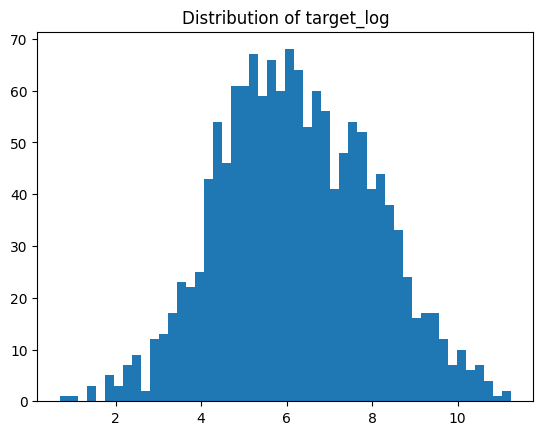

In [17]:
import matplotlib.pyplot as plt

plt.hist(y, bins=50)
plt.title("Distribution of target_log")
plt.show()

In [19]:
X['review_count_log'] = np.log1p(X['review_count'])
X.drop(columns=['review_count'], inplace=True)

In [20]:
X['Discount Rate'] = np.clip(
    X['Discount Rate'],
    0,
    X['Discount Rate'].quantile(0.99)
)

In [21]:
X = X.drop(columns=['pct_neu'])

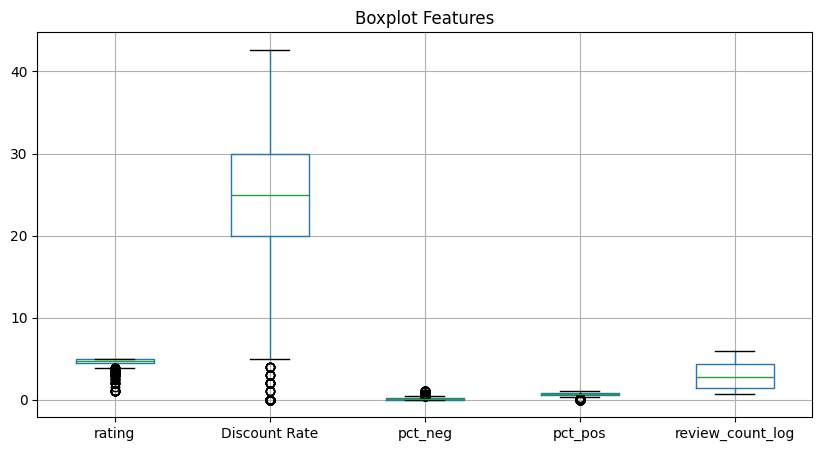

In [22]:
X.boxplot(figsize=(10,5))
plt.title("Boxplot Features")
plt.show()

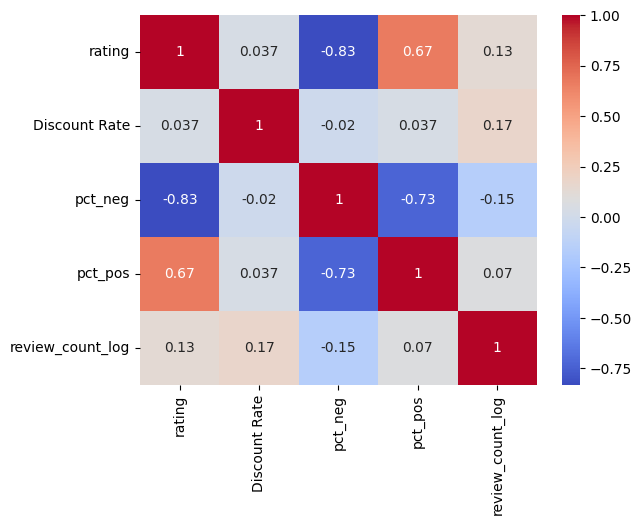

In [23]:
import seaborn as sns

sns.heatmap(X.corr(), annot=True, cmap='coolwarm')
plt.show()

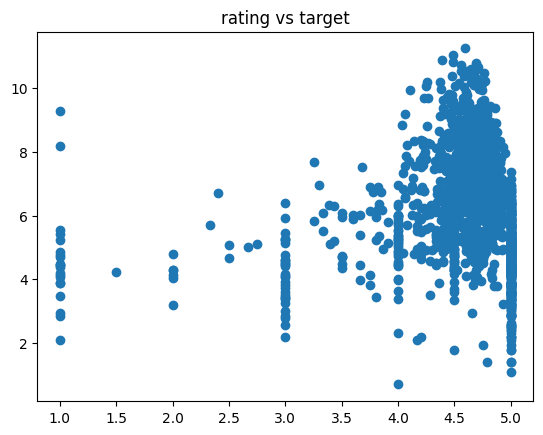

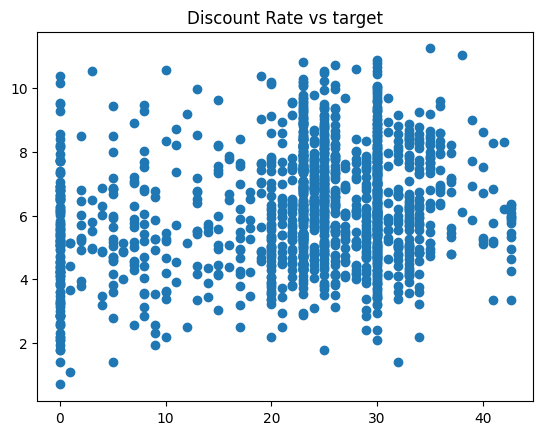

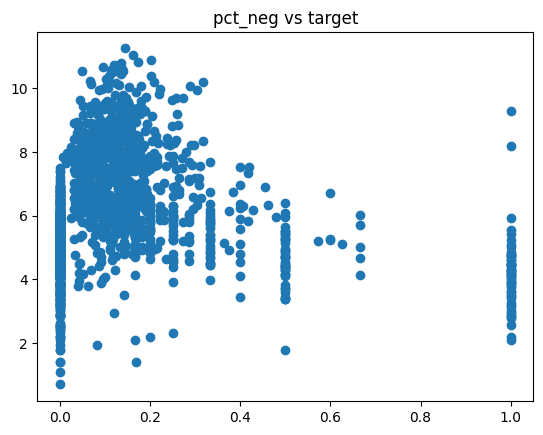

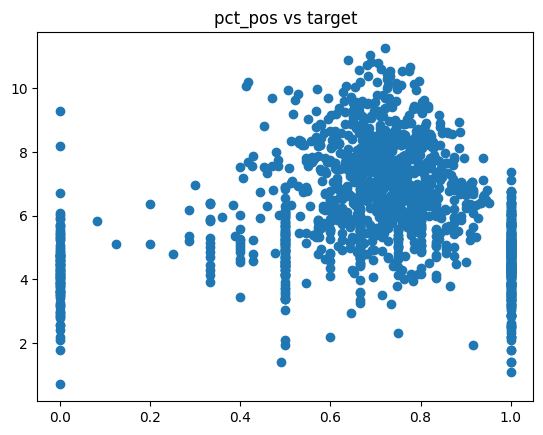

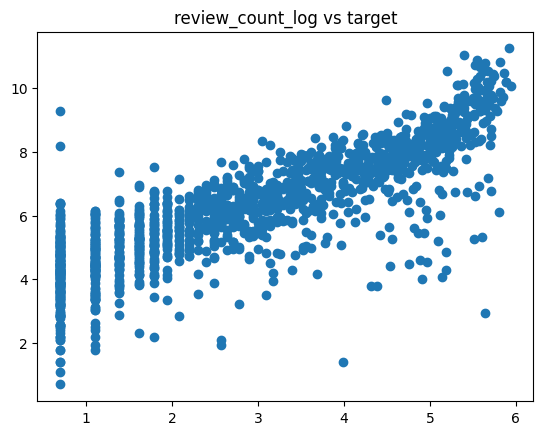

In [24]:
for col in X.columns:
    plt.scatter(X[col], y)
    plt.title(f"{col} vs target")
    plt.show()

In [25]:
from IPython.display import display

display(processed_data.head())

,review_count,rating,Sales Count,Discount Rate,pct_neg,pct_neu,pct_pos,target_log
0,194,4.592784,1647,0,0.103093,0.139175,0.757732,7.407318
1,202,4.673267,24533,26,0.103960,0.138614,0.757426,10.107815
2,8,4.250000,415,25,0.000000,0.000000,0.999999,6.030685
3,181,4.685083,38135,30,0.049724,0.176796,0.773481,10.548914
4,12,4.750000,6,0,0.083333,0.000000,0.916666,1.945910


In [34]:
print("--- Dữ liệu X (features) sau cùng ---\n")
print(X.head())

print("\n--- Dữ liệu y (target) sau cùng ---\n")
print(y.head())

print("\n--- Các cột feature cuối cùng được sử dụng ---\n")
print(X.columns.tolist())

--- Dữ liệu X (features) sau cùng ---

     rating  Discount Rate   pct_neg   pct_pos  review_count_log
0  4.592784            0.0  0.103093  0.757732          5.273000
1  4.673267           26.0  0.103960  0.757426          5.313206
2  4.250000           25.0  0.000000  0.999999          2.197225
3  4.685083           30.0  0.049724  0.773481          5.204007
4  4.750000            0.0  0.083333  0.916666          2.564949

--- Dữ liệu y (target) sau cùng ---

0     7.407318
1    10.107815
2     6.030685
3    10.548914
4     1.945910
Name: target_log, dtype: float64

--- Các cột feature cuối cùng được sử dụng ---

['rating', 'Discount Rate', 'pct_neg', 'pct_pos', 'review_count_log']


# Train Model

## XGBoot

## LightGBM

## Random Forest.